# Keşif

In [ ]:
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2
import os

## Veriyi Al

In [31]:
import sys
sys.path.append('/home/mert/Sprint-15')

In [32]:
from olist.data import Olist
data = Olist().get_data()

Olist e-ticaret platformundaki her işlem şu özelliklere sahiptir:
- satın alacak olan bir `customer_id`...
- çeşitli `product_id`...
- bir `seller_id`...
- ve bir `review_id`...
- tüm bunlar bir `order_id`'ye aittir.

## Çeşitli DataFrame'lerinizin kardinalitelerini araştırın

❓ **Kaç tane benzersiz `orders`, `reviews`, `sellers`, `products` and `customers` var ?**

In [38]:
unique_counts = [
    data["orders"].order_id.nunique(),
    data["order_reviews"].review_id.nunique(),
    data["sellers"].seller_id.nunique(),
    data["products"].product_id.nunique(),
    data["customers"].customer_id.nunique(),
]

total_counts = [
    data["orders"].order_id.count(),
    data["order_reviews"].review_id.count(),
    data["sellers"].seller_id.count(),
    data["products"].product_id.count(),
    data["customers"].customer_id.count(),
]

# ratio
ratios = [u / t for u, t in zip(unique_counts, total_counts)]

# DataFrame
df = pd.DataFrame(
    {
        'nunique': unique_counts,
        'count': total_counts,
        'ratio': ratios
    },
    index=['orders', 'reviews', 'sellers', 'products', 'customers']
)
df

,nunique,count,ratio
orders,99441,99441,1.000000
reviews,98410,99224,0.991796
sellers,3095,3095,1.000000
products,32951,32951,1.000000
customers,99441,99441,1.000000


In [72]:
aggregates = np.array([
    [
        data["orders"].order_id.nunique(),
        data["order_reviews"].review_id.nunique(),
        data["sellers"].seller_id.nunique(),
        data["products"].product_id.nunique(),
        data["customers"].customer_id.nunique(),
    ],
    [
        data["orders"].order_id.count(),
        data["order_reviews"].review_id.count(),
        data["sellers"].seller_id.count(),
        data["products"].product_id.count(),
        data["customers"].customer_id.count(),
    ],
])
pd.DataFrame(data=np.vstack((aggregates, aggregates[0,:]/aggregates[1,:])).T,
             index=['orders', 'reviews', 'sellers', 'products', 'customers'],
            columns=['nunique', 'count','ratio'])


,nunique,count,ratio
orders,99441.0,99441.0,1.000000
reviews,98410.0,99224.0,0.991796
sellers,3095.0,3095.0,1.000000
products,32951.0,32951.0,1.000000
customers,99441.0,99441.0,1.000000


❓ **Sipariş başına kaç tane yorum(reviews) var? Tüm siparişler için yorum var mı?**
<details>
    <summary markdown=‘span’>İpuçları</summary>

Bu bilgiye bireysel csv dosyanızdan doğrudan erişemezsiniz. Öğrenmek için tabloları birleştirmeniz gerekir. Hangi tür birleştirme yapmanız gerektiğini düşünün.

Hangi tablolara ihtiyacınız olduğundan emin değil misiniz? Öğrenmek için ERD'nize geri dönün.

Yorum sayısını öğrenmek için: `order_id` başına yorum sayısını sayın ve bir histogram çizin. Pandas serisinde `.hist()` kullanabilirsiniz.
</details>

In [77]:
# YOUR CODE HERE
orders = data['orders'][['customer_id','order_id']]
reviews = data['order_reviews'][['review_id','order_id']]

orders_reviews = orders.merge(reviews,on='order_id',how='outer')
orders_reviews.head()

,customer_id,order_id,review_id
0,3ce436f183e68e07877b285a838db11a,00010242fe8c5a6d1ba2dd792cb16214,97ca439bc427b48bc1cd7177abe71365
1,f6dd3ec061db4e3987629fe6b26e5cce,00018f77f2f0320c557190d7a144bdd3,7b07bacd811c4117b742569b04ce3580
2,6489ae5e4333f3693df5ad4372dab6d3,000229ec398224ef6ca0657da4fc703e,0c5b33dea94867d1ac402749e5438e8b
3,d4eb9395c8c0431ee92fce09860c5a06,00024acbcdf0a6daa1e931b038114c75,f4028d019cb58564807486a6aaf33817
4,58dbd0b2d70206bf40e62cd34e84d795,00042b26cf59d7ce69dfabb4e55b4fd9,940144190dcba6351888cafa43f3a3a5


In [80]:
orders_reviews.describe()

,customer_id,order_id,review_id
count,99992,99992,99224
unique,99441,99441,98410
top,ae0fb7b01c548c4fd30f19f55453ec4a,c88b1d1b157a9999ce368f218a407141,9e25d6e3025e9b9a0fc7f03588d33e2b
freq,3,3,3


In [78]:
orders_reviews.isna().sum()

customer_id      0
order_id         0
review_id      768
dtype: int64

<Axes: >

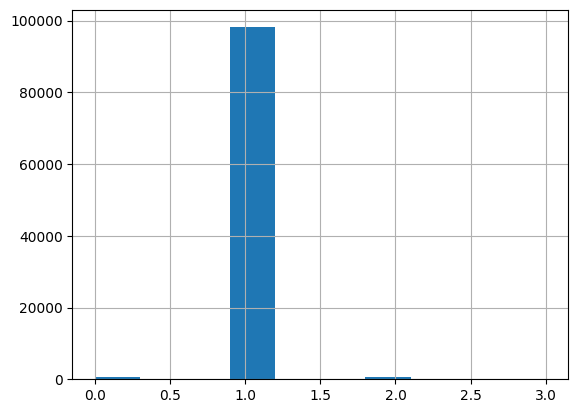

In [86]:
orders_reviews.groupby('order_id')['review_id'].count().hist()


🧪 **Test your code below**

Yorum eksik olan siparişlerin sayısını `int` olarak `n_missing_reviews` adlı bir değişkende saklayın.

In [90]:
n_missing_reviews = orders_reviews.isna().sum()['review_id']
n_missing_reviews

768

In [89]:
from nbresult import ChallengeResult

result = ChallengeResult('exploratory',
    n=n_missing_reviews
)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/mert/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/mert/Sprint-15/01-Statistical-Inference/data-exploratory-analysis/tests
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_exploratory.py::TestExploratory::test_n_missing_reviews PASSED      [100%]

============================== 1 passed in 0.28s ===============================


💯 You can commit your code:

git add tests/exploratory.pickle

git commit -m 'Completed exploratory step'

git push origin master

